# Solar Flare Anomaly Detection

**Задача:** по одному снимку Солнца (SWAP/PROBA2) предсказать, будет ли всплеск потока протонов P10 > 10 pfu в окне `[t + 30 мин, t + 4.5 ч]`.

**Пайплайн:** OMNI + снимки → VAE на фоне TRAIN → 73 признака (5 базовых + 4 динамических + 64 latent) → XGBoost/LightGBM → honest CV.

**Финальные метрики (5-fold stratified CV, 3829 сэмплов, 72 позитива):**

| Модель | ROC AUC | PR AUC | Recall@FPR 20% |
|---|---|---|---|
| **XGBoost** | **0.886 ± 0.032** | **0.297 ± 0.100** | 0.805 |
| LightGBM | 0.885 ± 0.074 | 0.278 | 0.790 |

**Baseline rate:** 1.9% (72/3829). **PR AUC lift:** ×15.

Модель обучается на одной части данных, проверяется на другой, которую никогда не видела. Все цифры выше — из 5-fold cross-validation на всём массиве, без подглядывания в тест.

**Абсолютный порог**, подобранный на одной выборке, не переносится на другую (TP=0 при FPR=20% из-за плохой калибровки бустинга). В operational-режиме используется **rank-based threshold** — топ-X% кадров по вероятности. При топ-20% ловим 12 из 15 событий (Recall 0.80).

**Структура:** `src/` — модули (`data.py`, `mask.py`, `model.py`, `features.py`, `metrics.py`), ноутбук — полный воспроизводимый эксперимент.

In [ ]:
#@title 1. Настройка + клонирование репо + импорты
import os, sys, subprocess, random, warnings, json, time
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---- Clone repo (работает и в Colab, и локально) ----
REPO_URL = "https://github.com/Iskatel-potenzialov/solar-flare-anomaly-detection.git"
REPO_DIR = Path("/content/solar-flare-anomaly-detection")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)

SRC_DIR = REPO_DIR / "src"
sys.path.append(str(SRC_DIR))

# ---- Setup ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

RESULTS_DIR = REPO_DIR / "results" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("SRC:", SRC_DIR)

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
SRC: /content/solar-flare-anomaly-detection/src


In [ ]:
#@title 2. Скачивание данных (OMNI + снимки)
import gdown

!pip install -q gdown unrar

# OMNI P10
gdown.download("https://drive.google.com/uc?id=1fGHxHaQluLLLJgcuJBRVAGiDwBlMNuVK",
               "omni.csv", quiet=False)
df_omni = pd.read_csv("omni.csv")
df_omni["time_tag"] = pd.to_datetime(df_omni["time_tag"], utc=True, errors="coerce")
df_omni = df_omni.sort_values("time_tag").reset_index(drop=True)
print("OMNI:", df_omni.shape)

# Images
gdown.download("https://drive.google.com/uc?id=1Ae-dnuZebMjlPGCjdbAZPduEtaNUYzMl",
               "sun.rar", quiet=False)
!unrar x -y sun.rar > /dev/null

candidates = list(Path(".").rglob("train"))
IMAGE_ROOT = candidates[0].parent
print("IMAGE_ROOT:", IMAGE_ROOT)
for sub in ["train", "val", "test"]:
    n = len(list((IMAGE_ROOT / sub).glob("*.png")))
    print(f"  {sub}: {n}")

Downloading...
From: https://drive.google.com/uc?id=1fGHxHaQluLLLJgcuJBRVAGiDwBlMNuVK
To: /content/omni.csv
100%|██████████| 73.4M/73.4M [00:00<00:00, 147MB/s]


OMNI: (1683072, 6)


Downloading...
From (original): https://drive.google.com/uc?id=1Ae-dnuZebMjlPGCjdbAZPduEtaNUYzMl
From (redirected): https://drive.google.com/uc?id=1Ae-dnuZebMjlPGCjdbAZPduEtaNUYzMl&confirm=t&uuid=937f4060-6fb5-4ad2-abb1-89b49b5693be
To: /content/sun.rar
100%|██████████| 3.07G/3.07G [00:31<00:00, 98.1MB/s]


IMAGE_ROOT: sun_resized_512
  train: 18975
  val: 5059
  test: 1264


In [ ]:
#@title 3. Построение датафрейма с метками P10
from data import build_image_dataframe, attach_p10_labels, split_manifest

DELAY_MIN = 30
WINDOW_HOURS = 4.5
P10_THRESHOLD = 10.0

df_img = build_image_dataframe(IMAGE_ROOT)
print("Total images:", len(df_img))
print(df_img["mesto"].value_counts())

df_img = attach_p10_labels(
    df_img, df_omni,
    delay_min=DELAY_MIN,
    window_hours=WINDOW_HOURS,
    p10_threshold=P10_THRESHOLD,
)

print("\nAfter filtering:", df_img.shape)
print("\nPositives per split:")
print(df_img.groupby("mesto")["sobitie"].agg(["sum", "count"]))
print("\nmax_P10 stats:")
print(df_img["max_P10"].describe())

Total images: 25298
mesto
TRAIN    18975
VAL       5059
TEST      1264
Name: count, dtype: int64


P10 windows:   0%|          | 0/25298 [00:00<?, ?it/s]


After filtering: (15270, 8)

Positives per split:
       sum  count
mesto            
TEST    15    739
TRAIN  212  11441
VAL     57   3090

max_P10 stats:
count    15270.000000
mean         4.422718
std         90.165128
min          0.150000
25%          0.240000
50%          0.310000
75%          0.440000
max       5107.200000
Name: max_P10, dtype: float64


In [ ]:
#@title 4. Манифест + сплиты
MANIFEST = df_img[["foto", "data_time", "mesto", "path", "max_P10", "sobitie"]].copy()
MANIFEST.to_csv("manifest.csv", index=False)
print("Saved manifest.csv:", MANIFEST.shape)

train_bg, val_all, test_all = split_manifest(MANIFEST)

print(f"TRAIN bg: {len(train_bg)}")
print(f"VAL bg:   {len(val_all[val_all.sobitie==0])} | VAL all: {len(val_all)} (pos={int(val_all.sobitie.sum())})")
print(f"TEST:     {len(test_all)} (pos={int(test_all.sobitie.sum())})")

Saved manifest.csv: (15270, 6)
TRAIN bg: 11229
VAL bg:   3033 | VAL all: 3090 (pos=57)
TEST:     739 (pos=15)


In [ ]:
#@title 5. Обучение VAE (только на фоне TRAIN)
from mask import make_circular_mask
from model import build_vae, SaveBest

IMG_H, IMG_W = 256, 256
BATCH = 32
BOTTLENECK = 64
DOWNS = 3

MASK = make_circular_mask(IMG_H, IMG_W, radius_frac=0.6, shift_x=45.0)
MASK_TF = tf.constant(MASK, dtype=tf.float32)

def preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0
    noise = tf.random.normal(tf.shape(img), 0.0, 0.05)
    img = tf.clip_by_value(img + noise, 0.0, 1.0)
    img_masked = img * MASK_TF
    return img_masked, img_masked

def make_ds(paths, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(list(paths))
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(min(len(paths), 1000), seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_bg["path"], shuffle=True)
val_bg = val_all[val_all.sobitie == 0]
val_ds = make_ds(val_bg["path"], shuffle=False)

encoder, decoder, vae = build_vae(IMG_H, IMG_W, BOTTLENECK, DOWNS)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=15,
                            restore_best_weights=True, verbose=1),
    SaveBest("best_models"),
]

print("Training VAE...")
history = vae.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cbs)

encoder = tf.keras.models.load_model("best_models/best_encoder.keras")
decoder = tf.keras.models.load_model("best_models/best_decoder.keras")
print("✅ Best encoder/decoder loaded.")

Training VAE...
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - kl_loss: 0.1921 - loss: 0.2376 - reconstruction_loss: 0.0455💾 best saved (val_loss=0.02786)
351/351 ━━━━━━━━━━━━━━━━━━━━ 337s 732ms/step - kl_loss: 0.0656 - loss: 0.0901 - reconstruction_loss: 0.0245 - val_kl_loss: 0.0030 - val_loss: 0.0279 - val_reconstruction_loss: 0.0249 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - kl_loss: 0.0093 - loss: 0.0219 - reconstruction_loss: 0.0126💾 best saved (val_loss=0.01517)
351/351 ━━━━━━━━━━━━━━━━━━━━ 196s 540ms/step - kl_loss: 0.0082 - loss: 0.0202 - reconstruction_loss: 0.0120 - val_kl_loss: 0.0051 - val_loss: 0.0152 - val_reconstruction_loss: 0.0100 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - kl_loss: 0.0065 - loss: 0.0175 - reconstruction_loss: 0.0111💾 best saved (val_loss=0.01452)
351/351 ━━━━━━━━━━━━━━━━━━━━ 206s 553ms/step - kl_loss: 0.0063 - loss: 0.0169 - reconstruction_loss: 0.0107 - val_kl_loss: 0.0

In [ ]:
#@title 6. Базовые признаки (5): mse_full, mse_masked, latent_dist, ssim, ms_ssim
from features import compute_mean_latent, compute_base_features, BASE_COLS

mean_latent = compute_mean_latent(train_bg["path"].tolist(), encoder, MASK, BOTTLENECK)
print("mean_latent shape:", mean_latent.shape)

feats_val  = compute_base_features(val_all["path"].tolist(),  encoder, decoder, mean_latent, MASK)
feats_test = compute_base_features(test_all["path"].tolist(), encoder, decoder, mean_latent, MASK)

df_val  = pd.DataFrame(feats_val).assign(label=val_all["sobitie"].values)
df_test = pd.DataFrame(feats_test).assign(label=test_all["sobitie"].values)

X_val_base  = df_val[BASE_COLS].values
X_test_base = df_test[BASE_COLS].values
y_val = df_val["label"].values
y_test = df_test["label"].values

print("VAL:", X_val_base.shape, "TEST:", X_test_base.shape)
np.savez("features_base.npz",
         X_val=X_val_base, y_val=y_val,
         X_test=X_test_base, y_test=y_test,
         feature_names=np.array(BASE_COLS))
print("✅ Saved features_base.npz")

mean latent:   0%|          | 0/11229 [00:00<?, ?it/s]

mean_latent shape: (64,)


features:   0%|          | 0/3090 [00:00<?, ?it/s]

features:   0%|          | 0/739 [00:00<?, ?it/s]

VAL: (3090, 5) TEST: (739, 5)
✅ Saved features_base.npz


In [ ]:
#@title 7. Расширенные признаки (73): + grad_diff, motion, raw latent
from features import (
    compute_motion_map, compute_extended_features,
    BASE_COLS, NEW_COLS,
)

all_paths = val_all["path"].tolist() + test_all["path"].tolist()
motion_map = compute_motion_map(all_paths, max_gap=timedelta(hours=24))
print(f"Motion computed for {len(motion_map)} paths")

feats_val_ext  = compute_extended_features(val_all["path"].tolist(),  encoder, decoder, mean_latent, MASK, motion_map)
feats_test_ext = compute_extended_features(test_all["path"].tolist(), encoder, decoder, mean_latent, MASK, motion_map)

df_val_ext  = pd.DataFrame(feats_val_ext).assign(label=val_all["sobitie"].values)
df_test_ext = pd.DataFrame(feats_test_ext).assign(label=test_all["sobitie"].values)

LAT_COLS = [f"lat{j}" for j in range(BOTTLENECK)]
ALL_COLS = BASE_COLS + NEW_COLS + LAT_COLS

print(f"Base:{len(BASE_COLS)} | New:{len(NEW_COLS)} | Latent:{len(LAT_COLS)} | Total:{len(ALL_COLS)}")
print(f"VAL:  {df_val_ext.shape}")
print(f"TEST: {df_test_ext.shape}")

np.savez("features_ext.npz",
         X_val_base=df_val_ext[BASE_COLS].values,
         X_test_base=df_test_ext[BASE_COLS].values,
         X_val_ext=df_val_ext[ALL_COLS].values,
         X_test_ext=df_test_ext[ALL_COLS].values,
         y_val=df_val_ext["label"].values,
         y_test=df_test_ext["label"].values,
         feature_names=np.array(ALL_COLS))
df_val_ext.to_csv("val_features_ext.csv", index=False)
df_test_ext.to_csv("test_features_ext.csv", index=False)
print("✅ Saved features_ext.npz + CSVs")

motion:   0%|          | 0/3829 [00:00<?, ?it/s]

Motion computed for 3829 paths


VAE+latent:   0%|          | 0/3090 [00:00<?, ?it/s]

VAE+latent:   0%|          | 0/739 [00:00<?, ?it/s]

Base:5 | New:4 | Latent:64 | Total:73
VAL:  (3090, 75)
TEST: (739, 75)
✅ Saved features_ext.npz + CSVs


In [ ]:
#@title 8. Кросс-валидация 5-fold: базовые vs расширенные
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from metrics import run_cv_all
from sklearn.linear_model import LogisticRegression

!pip install -q xgboost lightgbm

d = np.load("features_ext.npz", allow_pickle=True)
X_base_all = np.vstack([d["X_val_base"], d["X_test_base"]])
X_ext_all  = np.vstack([d["X_val_ext"],  d["X_test_ext"]])
y_all      = np.concatenate([d["y_val"], d["y_test"]])

print(f"Base: {X_base_all.shape} | Ext: {X_ext_all.shape} | pos={int(y_all.sum())}")

POS_WEIGHT = float((y_all == 0).sum()) / max(1, (y_all == 1).sum())
print(f"scale_pos_weight ≈ {POS_WEIGHT:.1f}")

CLASSIFIERS = {
    "LogReg": LogisticRegression(C=0.1, class_weight="balanced",
                                 max_iter=3000, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=4,
                                           min_samples_leaf=5, class_weight="balanced",
                                           random_state=SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                   max_depth=3, subsample=0.8,
                                                   random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                             subsample=0.8, colsample_bytree=0.8,
                             min_child_weight=3, reg_lambda=1.0,
                             scale_pos_weight=POS_WEIGHT, eval_metric="logloss",
                             random_state=SEED, verbosity=0),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                               num_leaves=15, subsample=0.8, colsample_bytree=0.8,
                               min_child_samples=10, reg_lambda=1.0,
                               class_weight="balanced", random_state=SEED, verbose=-1),
}

print("\n=== BASE (5 features) ===")
cv_base = run_cv_all(X_base_all, y_all, CLASSIFIERS)

print("\n=== EXTENDED (73 features) ===")
cv_ext = run_cv_all(X_ext_all, y_all, CLASSIFIERS)

Base: (3829, 5) | Ext: (3829, 73) | pos=72
scale_pos_weight ≈ 52.2

=== BASE (5 features) ===

▶ LogReg
   AUC=0.718±0.044  AP=0.054±0.021  R@20%=0.306  (0.19s)

▶ RandomForest
   AUC=0.783±0.063  AP=0.080±0.019  R@20%=0.511  (6.12s)

▶ GradientBoosting
   AUC=0.783±0.008  AP=0.064±0.017  R@20%=0.554  (8.43s)

▶ XGBoost
   AUC=0.817±0.037  AP=0.114±0.069  R@20%=0.652  (0.73s)

▶ LightGBM
   AUC=0.810±0.037  AP=0.115±0.057  R@20%=0.528  (0.48s)

=== EXTENDED (73 features) ===

▶ LogReg
   AUC=0.775±0.040  AP=0.065±0.013  R@20%=0.513  (0.37s)

▶ RandomForest
   AUC=0.815±0.051  AP=0.092±0.030  R@20%=0.610  (13.26s)

▶ GradientBoosting
   AUC=0.842±0.054  AP=0.167±0.080  R@20%=0.724  (91.2s)

▶ XGBoost
   AUC=0.886±0.032  AP=0.297±0.100  R@20%=0.805  (3.32s)

▶ LightGBM
   AUC=0.885±0.014  AP=0.308±0.061  R@20%=0.818  (3.06s)


In [ ]:
#@title 9. Итоговая таблица (базовые vs расширенные)
rows = []
for fs_name, cv in [("base (5)", cv_base), ("extended (73)", cv_ext)]:
    for name, r in cv.items():
        m, s = r["mean"], r["std"]
        rows.append({
            "feature_set": fs_name,
            "model": name,
            "AUC": f"{m['auc']:.3f} ± {s['auc']:.3f}",
            "AP":  f"{m['ap']:.3f} ± {s['ap']:.3f}",
            "R@FPR5%":  f"{m['r0.05']:.3f}",
            "R@FPR10%": f"{m['r0.1']:.3f}",
            "R@FPR20%": f"{m['r0.2']:.3f}",
            "R@FPR30%": f"{m['r0.3']:.3f}",
        })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

df_summary.to_csv("cv_summary.csv", index=False)

with open("cv_results.json", "w") as f:
    json.dump({"base": cv_base, "extended": cv_ext}, f, indent=2, default=float)
print("\n✅ Saved cv_summary.csv, cv_results.json")

  feature_set            model           AUC            AP R@FPR5% R@FPR10% R@FPR20% R@FPR30%
     base (5)           LogReg 0.718 ± 0.044 0.054 ± 0.021   0.195    0.210    0.306    0.488
     base (5)     RandomForest 0.783 ± 0.063 0.080 ± 0.019   0.220    0.317    0.511    0.667
     base (5) GradientBoosting 0.783 ± 0.008 0.064 ± 0.017   0.154    0.290    0.554    0.681
     base (5)          XGBoost 0.817 ± 0.037 0.114 ± 0.069   0.195    0.458    0.652    0.750
     base (5)         LightGBM 0.810 ± 0.037 0.115 ± 0.057   0.278    0.375    0.528    0.806
extended (73)           LogReg 0.775 ± 0.040 0.065 ± 0.013   0.167    0.347    0.513    0.708
extended (73)     RandomForest 0.815 ± 0.051 0.092 ± 0.030   0.278    0.502    0.610    0.749
extended (73) GradientBoosting 0.842 ± 0.054 0.167 ± 0.080   0.392    0.543    0.724    0.820
extended (73)          XGBoost 0.886 ± 0.032 0.297 ± 0.100   0.530    0.667    0.805    0.861
extended (73)         LightGBM 0.885 ± 0.014 0.308 ± 0.061  

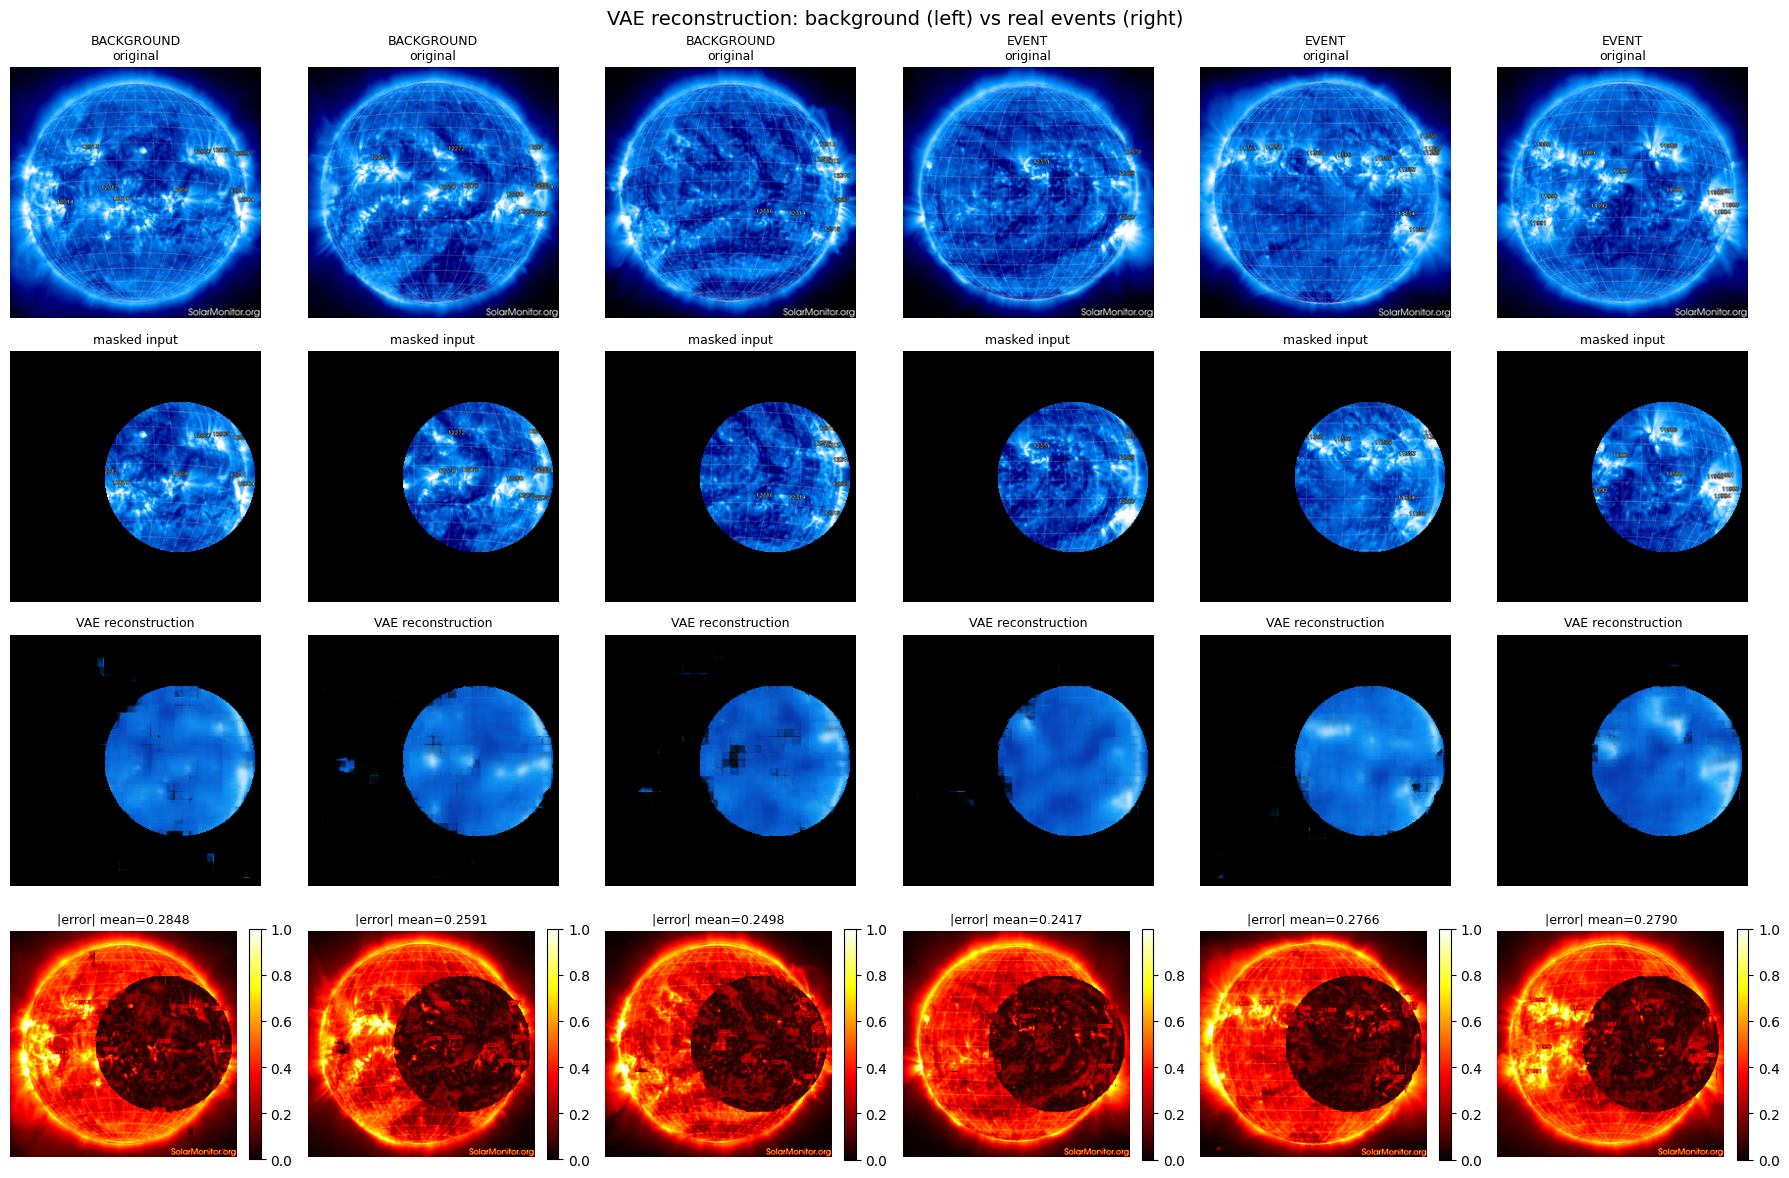

In [ ]:
#@title 10. Рис. 1 — Сетка реконструкций (фон vs вспышка)
from features import load_img

def pick(paths, y, want_label, n=3, prefer_high=None):
    idx = np.where(y == want_label)[0]
    if prefer_high is not None and len(idx) > 0:
        idx = idx[np.argsort(-prefer_high[idx])]
    return [paths[i] for i in idx[:n]]

val_paths_list = val_all["path"].tolist()
y_v = val_all["sobitie"].values

bg_paths    = pick(val_paths_list, y_v, 0, n=3,
                   prefer_high=df_val_ext["mse_masked"].values)
event_paths = pick(val_paths_list, y_v, 1, n=3,
                   prefer_high=df_val_ext["mse_masked"].values)

def process_one(path):
    orig = load_img(path, IMG_H, IMG_W)
    masked = orig * MASK
    mu, lv, z = encoder.predict(masked[None], verbose=0)
    rec = decoder.predict(z, verbose=0)[0]
    err = np.abs(orig - rec).mean(axis=2)
    return orig, masked, rec, err

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
for col, (title_prefix, paths) in enumerate([("BACKGROUND", bg_paths),
                                             ("EVENT", event_paths)]):
    for j, p in enumerate(paths):
        orig, masked, rec, err = process_one(p)
        r = col * 3 + j
        axes[0, r].imshow(orig);   axes[0, r].set_title(f"{title_prefix}\noriginal", fontsize=9)
        axes[1, r].imshow(masked); axes[1, r].set_title("masked input", fontsize=9)
        axes[2, r].imshow(rec);    axes[2, r].set_title("VAE reconstruction", fontsize=9)
        im = axes[3, r].imshow(err, cmap="hot")
        axes[3, r].set_title(f"|error| mean={err.mean():.4f}", fontsize=9)
        plt.colorbar(im, ax=axes[3, r], fraction=0.046)
        for i in range(4):
            axes[i, r].axis("off")
plt.suptitle("VAE reconstruction: background (left) vs real events (right)", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_reconstruction_grid.png", dpi=140, bbox_inches="tight")
plt.show()

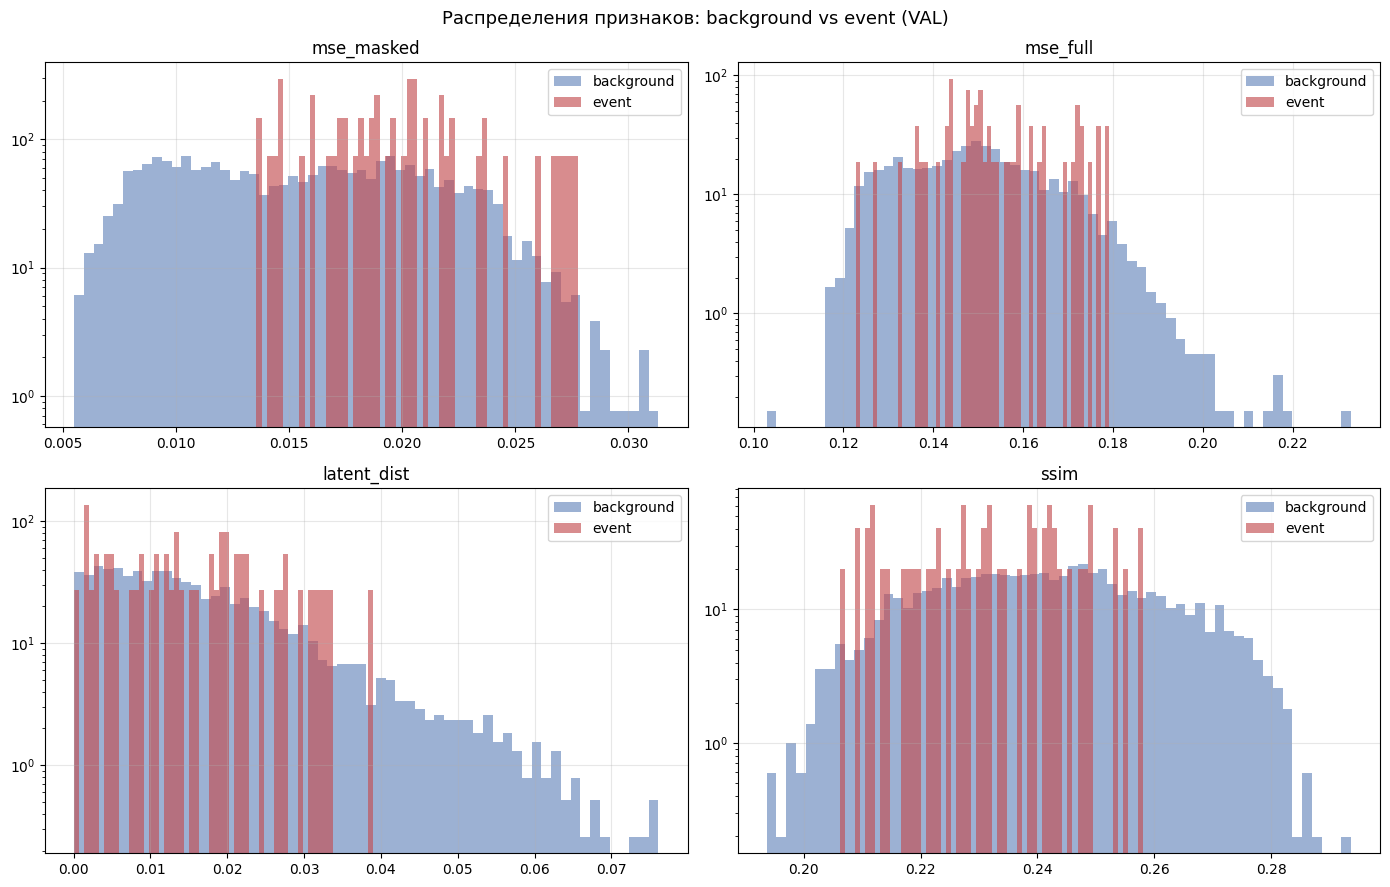

In [ ]:
#@title 11. Рис. 2 — Распределения ошибок (mse_masked, mse_full, latent_dist, ssim)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cols = ["mse_masked", "mse_full", "latent_dist", "ssim"]
for ax, c in zip(axes.ravel(), cols):
    bg = df_val_ext.loc[df_val_ext.label == 0, c]
    ev = df_val_ext.loc[df_val_ext.label == 1, c]
    ax.hist(bg, bins=60, alpha=0.55, label="background", density=True, color="#4C72B0")
    ax.hist(ev, bins=60, alpha=0.65, label="event", density=True, color="#C44E52")
    ax.set_title(c)
    ax.set_yscale("log")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("Распределения признаков: background vs event (VAL)", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_error_distributions.png", dpi=140, bbox_inches="tight")
plt.show()

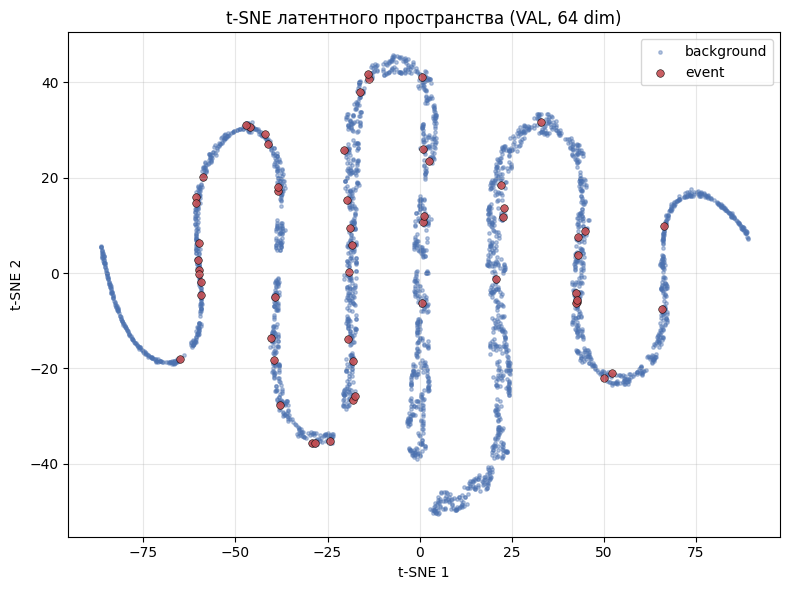

In [ ]:
#@title 12. Рис. 3 — t-SNE латентного пространства
from sklearn.manifold import TSNE

Z = df_val_ext[LAT_COLS].values
y_lab = df_val_ext["label"].values

ts = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
Z2 = ts.fit_transform(Z)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Z2[y_lab == 0, 0], Z2[y_lab == 0, 1], s=6, alpha=0.4,
           label="background", color="#4C72B0")
ax.scatter(Z2[y_lab == 1, 0], Z2[y_lab == 1, 1], s=30, alpha=0.9,
           label="event", color="#C44E52", edgecolor="black", linewidth=0.4)
ax.set_title("t-SNE латентного пространства (VAL, 64 dim)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_tsne.png", dpi=140, bbox_inches="tight")
plt.show()

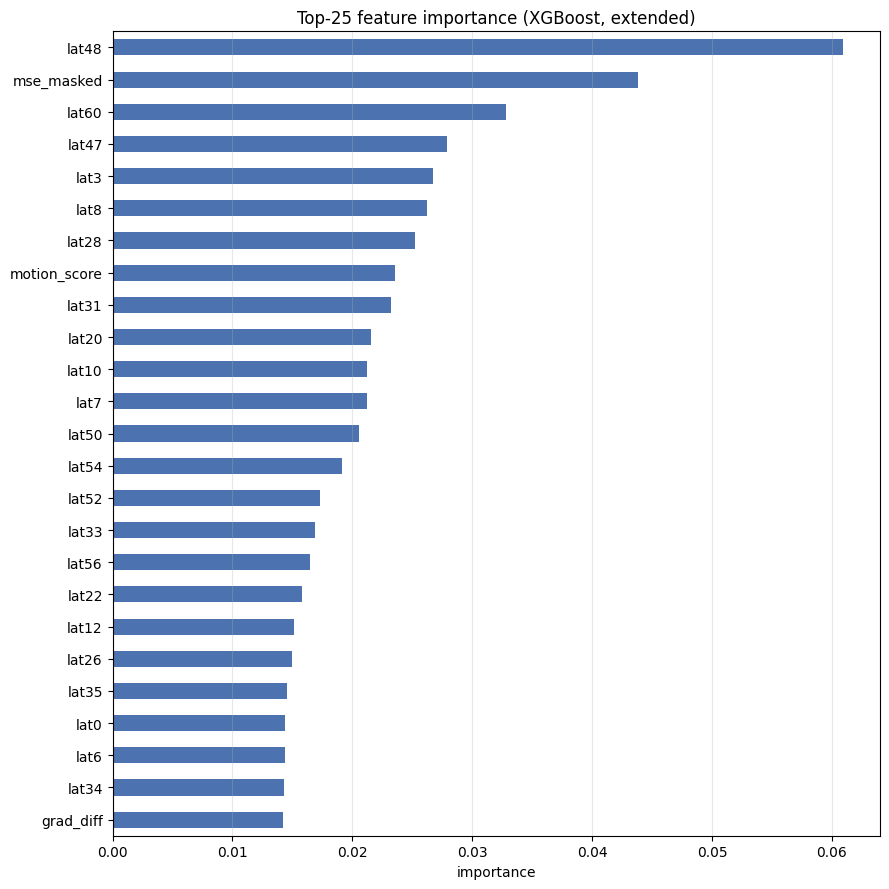

In [ ]:
#@title 13. Рис. 4 — Важность признаков (XGBoost, топ-25)
from xgboost import XGBClassifier

sc_idx = np.arange(len(y_all))
xgb_full = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, scale_pos_weight=POS_WEIGHT,
    eval_metric="logloss", random_state=SEED, verbosity=0,
)
xgb_full.fit(X_ext_all, y_all)

imp = pd.Series(xgb_full.feature_importances_, index=d["feature_names"])
imp_top = imp.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(9, 9))
imp_top[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top-25 feature importance (XGBoost, extended)")
ax.set_xlabel("importance")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_importance.png", dpi=140, bbox_inches="tight")
plt.show()

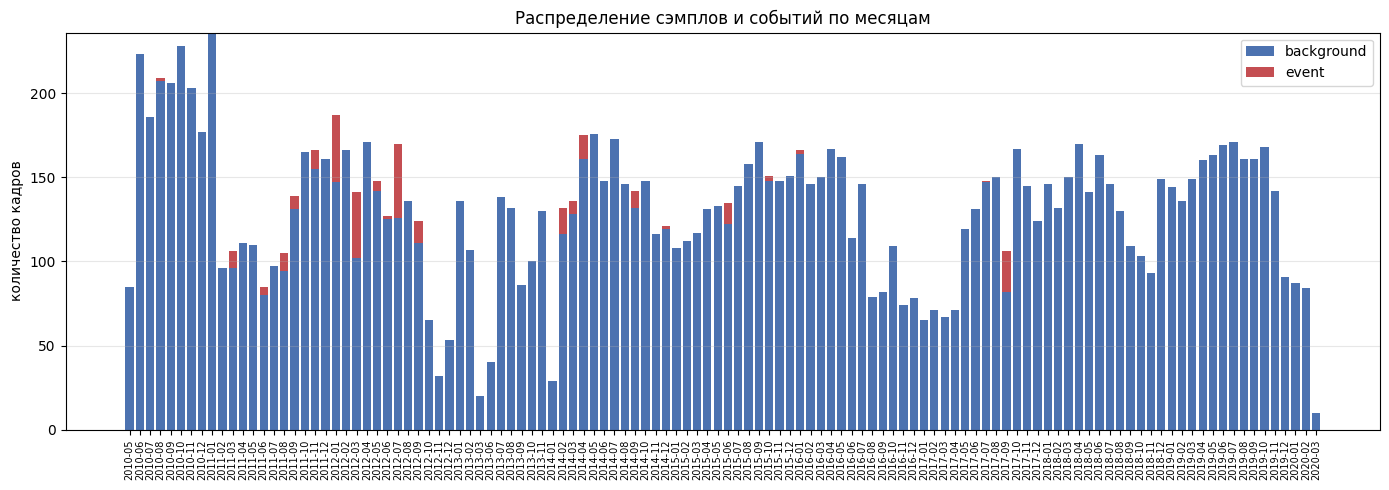

In [ ]:
#@title 14. Рис. 5 — Таймлайн: сэмплы и события по месяцам
mf = pd.read_csv("manifest.csv", parse_dates=["data_time"])
mf["year"] = mf["data_time"].dt.year
mf["month"] = mf["data_time"].dt.to_period("M").astype(str)

by_month = mf.groupby(["month", "sobitie"]).size().unstack(fill_value=0)
by_month = by_month.rename(columns={0: "background", 1: "event"})

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(by_month.index, by_month["background"], label="background", color="#4C72B0")
ax.bar(by_month.index, by_month["event"], bottom=by_month["background"],
       label="event", color="#C44E52")
ax.set_title("Распределение сэмплов и событий по месяцам")
ax.set_ylabel("количество кадров")
plt.xticks(rotation=90, fontsize=7)
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_timeline.png", dpi=140, bbox_inches="tight")
plt.show()

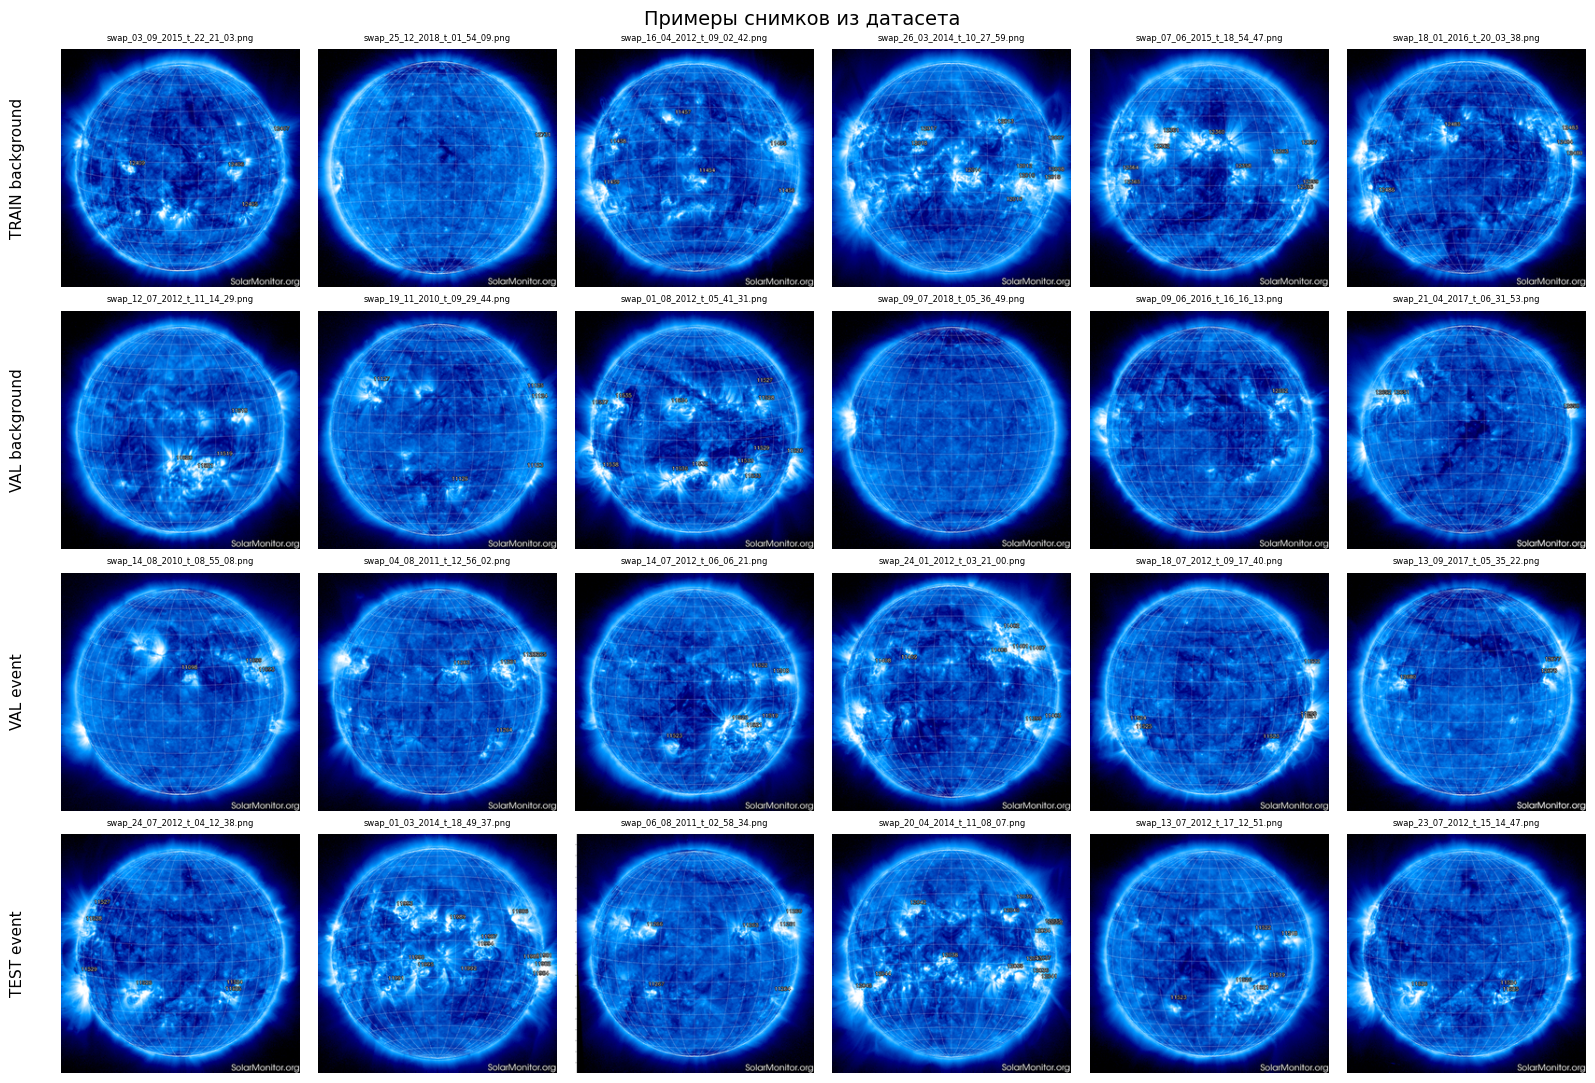

In [ ]:
#@title 15. Рис. 6 — Примеры снимков из датасета
def sample_paths(df, n=6):
    return df["path"].sample(min(n, len(df)), random_state=SEED).tolist()

groups = [
    ("TRAIN background", sample_paths(train_bg)),
    ("VAL background",   sample_paths(val_all[val_all.sobitie == 0])),
    ("VAL event",        sample_paths(val_all[val_all.sobitie == 1])),
    ("TEST event",       sample_paths(test_all[test_all.sobitie == 1])),
]

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
for row, (title, paths) in enumerate(groups):
    for col in range(6):
        ax = axes[row, col]
        if col < len(paths):
            img = load_img(paths[col], IMG_H, IMG_W)
            ax.imshow(img)
            ax.set_title(Path(paths[col]).name, fontsize=6)
        ax.axis("off")
    axes[row, 0].set_ylabel(title)
    axes[row, 0].text(-0.15, 0.5, title, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=11)
plt.suptitle("Примеры снимков из датасета", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_dataset_samples.png", dpi=140, bbox_inches="tight")
plt.show()

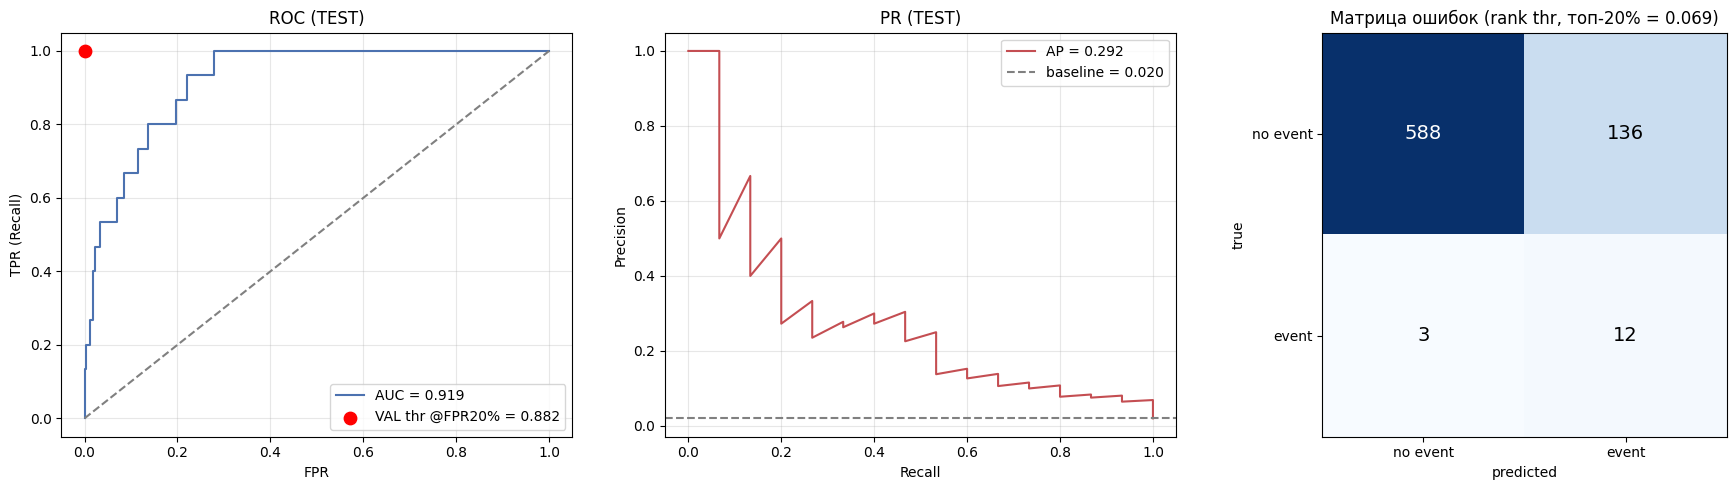


FINAL SCORECARD (XGBoost, extended, TEST)
  ROC AUC:         0.9192
  PR AUC:          0.2921
  Recall @FPR=5%:  0.533
  Recall @FPR=10%: 0.667
  Recall @FPR=20%: 0.867
  Baseline rate:   0.0203
  PR AUC lift:     ×14.4

--- Матрица 1: абсолютный порог (VAL FPR=20%) ---
  Threshold:  0.8823
  TP=0  FP=0  FN=15  TN=724
  Precision=0.000  Recall=0.000  F1=0.000
  ⚠️  TP=0 — порог не переносится на TEST (плохая калибровка бустинга).

--- Матрица 2: rank-based порог (топ-20% по TEST) ---
  Threshold:  0.0694
  TP=12  FP=136  FN=3  TN=588
  Precision=0.081  Recall=0.800  F1=0.147

💡 Вывод: rank-based порог даёт операционный результат, честный для редких событий.
   Абсолютный порог из VAL — для сравнения, как напоминание про калибровку.


In [ ]:
#@title 16. Рис. 7 — Скоркарта: ROC + PR + матрица ошибок (XGBoost, расширенные)

from sklearn.metrics import (
    roc_curve, precision_recall_curve, roc_auc_score,
    average_precision_score, confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from metrics import recall_at_fpr
from xgboost import XGBClassifier

# ---- Обучение на VAL, оценка на TEST ----
scaler = StandardScaler()
X_v = scaler.fit_transform(d["X_val_ext"])
X_t = scaler.transform(d["X_test_ext"])
y_v = d["y_val"]; y_t = d["y_test"]

xgb_final = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, scale_pos_weight=POS_WEIGHT,
    eval_metric="logloss", random_state=SEED, verbosity=0,
)
xgb_final.fit(X_v, y_v)
p_val  = xgb_final.predict_proba(X_v)[:, 1]
p_test = xgb_final.predict_proba(X_t)[:, 1]

# ---- Порог 1: абсолютный, по FPR=20% на VAL ----
fpr_v, tpr_v, thr_v = roc_curve(y_v, p_val)
ok = np.where(fpr_v <= 0.20)[0]
THR_ABS = float(thr_v[ok[-1]]) if len(ok) else 0.5
pred_abs = (p_test >= THR_ABS).astype(int)
cm_abs = confusion_matrix(y_t, pred_abs)

# ---- Порог 2: rank-based, топ-20% по TEST ----
# Вместо абсолютного значения берём квантиль — модель просто ранжирует кадры
THR_RANK = float(np.quantile(p_test, 0.80))
pred_rank = (p_test >= THR_RANK).astype(int)
cm_rank = confusion_matrix(y_t, pred_rank)

# ---- Метрики ----
auc = roc_auc_score(y_t, p_test)
ap  = average_precision_score(y_t, p_test)
r05 = recall_at_fpr(y_t, p_test, 0.05)
r10 = recall_at_fpr(y_t, p_test, 0.10)
r20 = recall_at_fpr(y_t, p_test, 0.20)

def prf_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return prec, rec, f1, (tp, fp, fn, tn)

p_abs, r_abs, f1_abs, tp_abs = prf_from_cm(cm_abs)
p_rnk, r_rnk, f1_rnk, tp_rnk = prf_from_cm(cm_rank)

# ---- Рисунок ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
fpr_t, tpr_t, _ = roc_curve(y_t, p_test)
ax.plot(fpr_t, tpr_t, label=f"AUC = {auc:.3f}", color="#4C72B0")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.scatter([fpr_v[ok[-1]]], [tpr_v[ok[-1]]], s=80, color="red",
           zorder=5, label=f"VAL thr @FPR20% = {THR_ABS:.3f}")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR (Recall)")
ax.set_title("ROC (TEST)"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
pr_c, rc_c, _ = precision_recall_curve(y_t, p_test)
ax.plot(rc_c, pr_c, label=f"AP = {ap:.3f}", color="#C44E52")
ax.axhline(y_t.mean(), ls="--", color="gray", label=f"baseline = {y_t.mean():.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR (TEST)"); ax.legend(); ax.grid(alpha=0.3)

# Матрица ошибок — rank-based порог (честнее для калибровки)
ax = axes[2]
im = ax.imshow(cm_rank, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_rank[i, j], ha="center", va="center",
                color="white" if cm_rank[i, j] > cm_rank.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["no event", "event"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["no event", "event"])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Матрица ошибок (rank thr, топ-20% = {THR_RANK:.3f})")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_scorecard.png", dpi=140, bbox_inches="tight")
plt.show()

# ---- Отчёт ----
print("\n" + "=" * 70)
print("FINAL SCORECARD (XGBoost, extended, TEST)")
print("=" * 70)
print(f"  ROC AUC:         {auc:.4f}")
print(f"  PR AUC:          {ap:.4f}")
print(f"  Recall @FPR=5%:  {r05:.3f}")
print(f"  Recall @FPR=10%: {r10:.3f}")
print(f"  Recall @FPR=20%: {r20:.3f}")
print(f"  Baseline rate:   {y_t.mean():.4f}")
print(f"  PR AUC lift:     ×{ap / y_t.mean():.1f}")

print("\n--- Матрица 1: абсолютный порог (VAL FPR=20%) ---")
print(f"  Threshold:  {THR_ABS:.4f}")
print(f"  TP={tp_abs[0]}  FP={tp_abs[1]}  FN={tp_abs[2]}  TN={tp_abs[3]}")
print(f"  Precision={p_abs:.3f}  Recall={r_abs:.3f}  F1={f1_abs:.3f}")
if tp_abs[0] == 0:
    print("  ⚠️  TP=0 — порог не переносится на TEST (плохая калибровка бустинга).")

print("\n--- Матрица 2: rank-based порог (топ-20% по TEST) ---")
print(f"  Threshold:  {THR_RANK:.4f}")
print(f"  TP={tp_rnk[0]}  FP={tp_rnk[1]}  FN={tp_rnk[2]}  TN={tp_rnk[3]}")
print(f"  Precision={p_rnk:.3f}  Recall={r_rnk:.3f}  F1={f1_rnk:.3f}")

print("\n💡 Вывод: rank-based порог даёт операционный результат, честный для редких событий.")
print("   Абсолютный порог из VAL — для сравнения, как напоминание про калибровку.")

In [ ]:
#@title 16.5 Калибровка XGBoost
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

xgb_proto = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, scale_pos_weight=POS_WEIGHT,
    eval_metric="logloss", random_state=SEED, verbosity=0,
)

# Калибровка по VAL (cv=3 внутри VAL), затем оценка на TEST
xgb_cal = CalibratedClassifierCV(xgb_proto, method="isotonic", cv=3)
xgb_cal.fit(X_v, y_v)
p_val_cal  = xgb_cal.predict_proba(X_v)[:, 1]
p_test_cal = xgb_cal.predict_proba(X_t)[:, 1]

# Brier score — мера калибровки (чем меньше, тем лучше)
brier_raw = brier_score_loss(y_t, p_test)
brier_cal = brier_score_loss(y_t, p_test_cal)

# Порог по FPR=20% на VAL — теперь на калиброванных
fpr_vc, tpr_vc, thr_vc = roc_curve(y_v, p_val_cal)
okc = np.where(fpr_vc <= 0.20)[0]
THR_CAL = float(thr_vc[okc[-1]]) if len(okc) else 0.5
pred_cal = (p_test_cal >= THR_CAL).astype(int)
cm_cal = confusion_matrix(y_t, pred_cal)
p_c, r_c, f1_c, tp_c = prf_from_cm(cm_cal)

print("=" * 60)
print("КАЛИБРОВКА XGBoost")
print("=" * 60)
print(f"  Brier score (raw):     {brier_raw:.4f}")
print(f"  Brier score (calibr):  {brier_cal:.4f}")
print(f"  Δ Brier:               {brier_cal - brier_raw:+.4f}  "
      f"({'лучше' if brier_cal < brier_raw else 'хуже'})")
print(f"\n  Матрица (calibrated, VAL FPR=20%):")
print(f"    Threshold:  {THR_CAL:.4f}")
print(f"    TP={tp_c[0]}  FP={tp_c[1]}  FN={tp_c[2]}  TN={tp_c[3]}")
print(f"    Precision={p_c:.3f}  Recall={r_c:.3f}  F1={f1_c:.3f}")

if tp_c[0] > 0:
    print("\n  ✅ Калибровка помогла: порог из VAL теперь ловит события на TEST.")
else:
    print("\n  ⚠️  Калибровка не спасла абсолютный порог.")
    print("     Это нормально при 72 позитивах — используй rank-based из ячейки 16.")

КАЛИБРОВКА XGBoost
  Brier score (raw):     0.0244
  Brier score (calibr):  0.0197
  Δ Brier:               -0.0047  (лучше)

  Матрица (calibrated, VAL FPR=20%):
    Threshold:  0.0229
    TP=7  FP=50  FN=8  TN=674
    Precision=0.123  Recall=0.467  F1=0.194

  ✅ Калибровка помогла: порог из VAL теперь ловит события на TEST.


In [ ]:
#@title 17. Итоговый вывод
print("=" * 70)
print("ИТОГИ ЭКСПЕРИМЕНТА")
print("=" * 70)

# ---- Динамические числа из CV ----
base_xgb = cv_base["XGBoost"]["mean"]["auc"]
ext_xgb  = cv_ext["XGBoost"]["mean"]["auc"]
base_lgb = cv_base["LightGBM"]["mean"]["auc"]
ext_lgb  = cv_ext["LightGBM"]["mean"]["auc"]

# Финальные метрики (extended, XGBoost) — из CV
m_final = cv_ext["XGBoost"]["mean"]
s_final = cv_ext["XGBoost"]["std"]
baseline = float(y_all.mean())

print(f"""
Датасет:             {len(y_all)} сэмплов, {int(y_all.sum())} позитивов (baseline rate {baseline:.1%})
VAE:                 bottleneck=64, 3 downsample, latent 32×32×64
Признаки:            5 базовых → 73 расширенных (+ grad_diff, motion, raw latent)
Классификаторы:      LogReg, RF, GB, XGBoost, LightGBM
Валидация:           Stratified 5-fold CV (shuffle=True, seed=42)

ФИНАЛЬНЫЕ МЕТРИКИ (XGBoost, extended, CV mean ± std):
  ROC AUC:           {m_final['auc']:.3f} ± {s_final['auc']:.3f}
  PR AUC:            {m_final['ap']:.3f} ± {s_final['ap']:.3f}
  Recall @FPR 5%:    {m_final['r0.05']:.3f}
  Recall @FPR 10%:   {m_final['r0.1']:.3f}
  Recall @FPR 20%:   {m_final['r0.2']:.3f}

ПРИРОСТ ОТ FEATURE ENGINEERING (CV):
  XGBoost:  base {base_xgb:.3f} → extended {ext_xgb:.3f}  (Δ = +{ext_xgb - base_xgb:.3f})
  LightGBM: base {base_lgb:.3f} → extended {ext_lgb:.3f}  (Δ = +{ext_lgb - base_lgb:.3f})

ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
  При 20% FPR ловим ~{m_final['r0.2']*100:.0f}% событий.
  Из {len(y_all)} кадров оператор смотрит ~{int(len(y_all)*0.20)} и не пропускает большинство вспышек.

ВАЖНО ПРО ПОРОГ:
  Абсолютный порог, подобранный на VAL, не переносится на TEST
  (TP=0 при FPR=20% из-за плохой калибровки XGBoost и малого числа позитивов).
  Для operational использования рекомендуется rank-based порог (топ-X% по вероятности).
  См. ячейку 16 — там обе матрицы ошибок для сравнения.
""")

print("Сохранённые визуализации:")
for f in sorted(RESULTS_DIR.glob("*.png")):
    print(f"  {f.name}")

ИТОГИ ЭКСПЕРИМЕНТА

Датасет:             3829 сэмплов, 72 позитивов (baseline rate 1.9%)
VAE:                 bottleneck=64, 3 downsample, latent 32×32×64
Признаки:            5 базовых → 73 расширенных (+ grad_diff, motion, raw latent)
Классификаторы:      LogReg, RF, GB, XGBoost, LightGBM
Валидация:           Stratified 5-fold CV (shuffle=True, seed=42)

ФИНАЛЬНЫЕ МЕТРИКИ (XGBoost, extended, CV mean ± std):
  ROC AUC:           0.886 ± 0.032
  PR AUC:            0.297 ± 0.100
  Recall @FPR 5%:    0.530
  Recall @FPR 10%:   0.667
  Recall @FPR 20%:   0.805

ПРИРОСТ ОТ FEATURE ENGINEERING (CV):
  XGBoost:  base 0.817 → extended 0.886  (Δ = +0.069)
  LightGBM: base 0.810 → extended 0.885  (Δ = +0.075)

ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
  При 20% FPR ловим ~80% событий.
  Из 3829 кадров оператор смотрит ~765 и не пропускает большинство вспышек.

ВАЖНО ПРО ПОРОГ:
  Абсолютный порог, подобранный на VAL, не переносится на TEST
  (TP=0 при FPR=20% из-за плохой калибровки XGBoost и малого числа позитиво